TIFF TO GENERIC BINARY CONVERTER

In [ ]:
pip install rasterio

In [ ]:
import numpy as np
import rasterio
from osgeo import gdal
import os

def tiff_to_bil(tiff_path, output_path_prefix):

    with rasterio.open(tiff_path) as src:
        data = src.read()  # Shape: (bands, rows, cols)
        bands, rows, cols = data.shape

        # Interleave as BIL (Band Interleaved by Line)
        bil_data = np.empty((rows, cols, bands), dtype=np.uint16)
        for b in range(bands):
            bil_data[:, :, b] = data[b, :, :]

        # Reshape to (rows*cols, bands) and write as binary
        bil_reshaped = bil_data.transpose(0, 2, 1).reshape(-1, bands)
        bil_flat = bil_reshaped.astype(np.uint16)

        bil_filename = f"{output_path_prefix}.bil"
        hdr_filename = f"{output_path_prefix}.hdr"

        # Save BIL
        with open(bil_filename, "wb") as f:
            f.write(bil_flat.tobytes())

        # Write ENVI HDR file
        with open(hdr_filename, "w") as f:
            f.write("ENVI\n")
            f.write(f"samples = {cols}\n")
            f.write(f"lines   = {rows}\n")
            f.write(f"bands   = {bands}\n")
            f.write("header offset = 0\n")
            f.write("file type = ENVI Standard\n")
            f.write("data type = 12\n")  # 12 = uint16
            f.write("interleave = bil\n")
            f.write("byte order = 1\n")

        print(f"✔️ Saved: {bil_filename} and {hdr_filename}")

# === Example Usage ===
tiff_path = "stackApril15Subset.tif"
output_prefix = "Narmadapuram"  # No extension
tiff_to_bil(tiff_path, output_prefix)


✔️ Saved: Narmadapuram.bil and Narmadapuram.hdr


1D-CNN MODEL

In [20]:
!apt-get install -y libgdal-dev
!pip install --upgrade pip
!pip install GDAL==3.6.0

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgdal-dev is already the newest version (3.8.4+dfsg-1~jammy0).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [3]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 595.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


number of classes ==> 3
train directory ==> /content/drive/MyDrive/Hackathon_Annam.AI/paddy sburnt train
test directory ==> /content/drive/MyDrive/Hackathon_Annam.AI/paddy burnt test
Image dimensions: 798 x 1248, Bands: 2, Type: U8
Give Label to PaddyburntSig: 1
Give Label to stubble_urban_sig: 0
Give Label to stubble_road_sig: 2

Assigned class labels:
PaddyburntSig: 1
stubble_urban_sig: 0
stubble_road_sig: 2
PaddyburntSig ==> 6 samples
stubble_urban_sig ==> 19 samples
stubble_road_sig ==> 9 samples
Class imbalance ratio: 3.17

Building model for input shape: [2, 1]
Using simplified architecture for low-dimensional data

Class weights: {np.int64(0): np.float64(0.5964912280701754), np.int64(1): np.float64(1.8888888888888888), np.int64(2): np.float64(1.2592592592592593)}


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_100 (Conv1D)             │ (None, 2, 32)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 2, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_101 (Conv1D)             │ (None, 2, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 2, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_102 (Conv1D)             │ (None, 1, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,827 (85.26 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.2412 - loss: 1.3983 - val_accuracy: 0.0000e+00 - val_loss: 1.1068
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2764 - loss: 1.3873 - val_accuracy: 0.0000e+00 - val_loss: 1.1351
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3375 - loss: 0.9849 - val_accuracy: 0.0000e+00 - val_loss: 1.1534
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3940 - loss: 0.9631 - val_accuracy: 0.0000e+00 - val_loss: 1.1673
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4569 - loss: 1.2155 - val_accuracy: 0.0000e+00 - val_loss: 1.1732
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4954 - loss: 0.7126 - val_accuracy: 0.0000e+00 - val_loss: 1.1815
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5560 - loss: 0.7327 - val_accuracy: 0.0000e+00 - val_loss: 1.1944
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5222 - loss: 0.6224 - val


Model saved as 'trained_model.h5'

=== Classification Report on Training Data ===
              precision    recall  f1-score   support

     Class_0       0.68      1.00      0.81        19
     Class_1       1.00      0.83      0.91         6
     Class_2       0.00      0.00      0.00         9

    accuracy                           0.71        34
   macro avg       0.56      0.61      0.57        34
weighted avg       0.56      0.71      0.61        34

Cohen Kappa Score on Training Data: 0.41880341880341887

=== Prediction Analysis ===
Class 0: 19 actual, 28 predicted, 19 correct
Class 1: 6 actual, 5 predicted, 5 correct
Class 2: 9 actual, 1 predicted, 0 correct


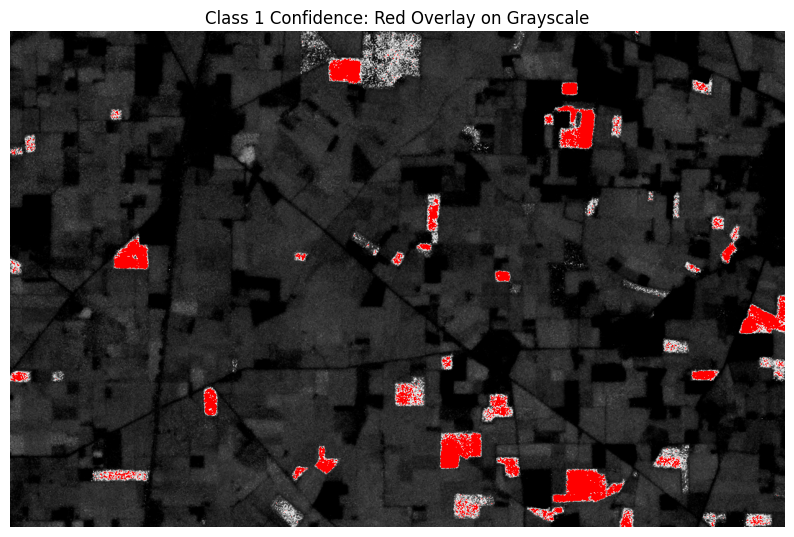

In [27]:
import os
import numpy as np
from osgeo import gdal
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dropout, Dense, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, cohen_kappa_score
from keras.models import load_model
from PIL import Image
import array
import sys
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def hdr_read(path):
    row, col, bands, datatype = 0, 0, 0, None
    with open(path, "r") as f:
        for l in f:
            k = l.strip().split()
            if not k:
                continue
            if k[0].lower() in ["bands:", "bands", "band:"]:
                bands = int(k[-1])
            elif k[0].lower() in ['rows:', 'rows', 'row:']:
                row = int(k[-1])
            elif k[0].lower() in ['cols:', 'cols', 'col:']:
                col = int(k[-1])
            elif k[0].lower() in ['datatype:', 'datatype']:
                datatype = k[-1]
    return row, col, bands, datatype

def ReadBilFile(bil_path, bands, pixels):
    image = np.zeros([pixels, bands], dtype=np.uint16)
    gdal.GetDriverByName('EHdr').Register()
    img = gdal.Open(bil_path)
    for b in range(bands):
        bandx = img.GetRasterBand(b + 1)
        datax = bandx.ReadAsArray()
        image[:, b] = datax.reshape(-1)
    return image

def write_bil_and_hdr(output_array, row, col, out_path):
    output_array = output_array.astype(np.uint8).reshape(row, col)
    output_array.tofile(out_path + ".bil")
    with open(out_path + ".hdr", 'w') as f:
        f.write("ENVI\n")
        f.write(f"samples = {col}\n")
        f.write(f"lines   = {row}\n")
        f.write("bands   = 1\n")
        f.write("header offset = 0\n")
        f.write("file type = ENVI Standard\n")
        f.write("data type = 1\n")  # 1 = 8-bit byte
        f.write("interleave = bsq\n")
        f.write("byte order = 0\n")

def train(train_dir, test_dir, num_classes):
    train_files = os.listdir(train_dir)
    test_files = os.listdir(test_dir)

    hdr_file = [f for f in train_files if f.lower().endswith('.hdr')]
    if not hdr_file:
        print("No .hdr file found in training directory!")
        return

    row, col, bands, datatype = hdr_read(os.path.join(train_dir, hdr_file[0]))
    if bands == 0:
        print("Error reading .hdr file or bands=0!")
        return

    print(f"Image dimensions: {row} x {col}, Bands: {bands}, Type: {datatype}")
    pixels = row * col
    mul, dtype = (255, np.uint8) if datatype == 'U8' else ((2 ** 16 - 1), np.uint16)

    bil_test_files = [f for f in test_files if not f.lower().endswith('.hdr') and not os.path.isdir(os.path.join(test_dir, f))]
    x_test = []
    for file in bil_test_files:
        temp = ReadBilFile(os.path.join(test_dir, file), bands, pixels)
        x_test.append(temp.reshape(row * col, bands, 1) / mul)

    bil_train_files = [f for f in train_files if not f.lower().endswith('.hdr') and not os.path.isdir(os.path.join(train_dir, f))]
    class_labels = {}
    for f in bil_train_files:
        label = int(input(f"Give Label to {f}: "))
        class_labels[f] = label

    print("\nAssigned class labels:")
    for k, v in class_labels.items():
        print(f"{k}: {v}")

    uniform_samples = 800  # Increased sample size
    clicks = {}
    for f in bil_train_files:
        path = os.path.join(train_dir, f)
        size_bytes = os.path.getsize(path)
        clicks[f] = min(size_bytes // 2 // bands, uniform_samples)
        print(f"{f} ==> {clicks[f]} samples")

    all_values = []
    y_train = []
    for f in bil_train_files:
        n_clicks = clicks[f]
        label = class_labels[f]
        with open(os.path.join(train_dir, f), "rb") as file:
            b = array.array("H")
            b.fromfile(file, n_clicks * bands)
            if sys.byteorder == "little":
                b.byteswap()
            for i in range(n_clicks):
                all_values.append(b[i * bands:(i + 1) * bands])
                y_train.append(label)

    x_train = np.array(all_values, dtype=dtype) / mul
    y_train = to_categorical(y_train, num_classes=num_classes)
    x_train = x_train.reshape(x_train.shape[0], bands, 1)

    # Check class distribution
    unique, counts = np.unique(np.argmax(y_train, axis=1), return_counts=True)
    class_distribution = dict(zip(unique, counts))
    #print("\nTraining samples per class:", class_distribution)

    # Check for class imbalance
    min_samples = min(counts)
    max_samples = max(counts)
    imbalance_ratio = max_samples / min_samples
    print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

    if imbalance_ratio > 3:
        print("WARNING: Significant class imbalance detected!")

    #print("\nFirst 10 labels (one-hot):", y_train[:10])
    #print("First 10 class indices:", np.argmax(y_train[:10], axis=1))

    # Build 1D CNN model - FIXED for small band dimensions
    model = Sequential()

    print(f"\nBuilding model for input shape: [{bands}, 1]")

    # For very small band counts (like 2), use a simpler architecture
    if bands <= 4:
        print("Using simplified architecture for low-dimensional data")

        # First block - no pooling to preserve dimensions
        model.add(Conv1D(32, 1, activation="relu", padding='same', input_shape=[bands, 1]))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))

        # Second block - careful pooling only if we have enough dimensions
        model.add(Conv1D(64, 1, activation="relu", padding='same'))
        model.add(BatchNormalization())
        if bands >= 2:
            model.add(MaxPooling1D(pool_size=min(2, bands), padding='same'))
        model.add(Dropout(0.2))

        # Use Global Average Pooling instead of regular pooling to avoid dimension issues
        model.add(Conv1D(128, 1, activation="relu", padding='same'))
        model.add(BatchNormalization())
        model.add(GlobalAveragePooling1D())  # This replaces Flatten and handles any input size
        model.add(Dropout(0.3))

    else:
        # Original architecture for higher dimensional data
        # First CNN block
        model.add(Conv1D(32, min(5, bands), activation="relu", padding='same', input_shape=[bands, 1]))
        model.add(BatchNormalization())
        model.add(Conv1D(32, min(3, bands), activation="relu", padding='same'))
        if bands >= 4:
            model.add(MaxPooling1D(2))
        model.add(Dropout(0.2))

        # Second CNN block
        model.add(Conv1D(64, min(3, bands//2 if bands >= 4 else bands), activation="relu", padding='same'))
        model.add(BatchNormalization())
        model.add(Conv1D(64, min(3, bands//2 if bands >= 4 else bands), activation="relu", padding='same'))
        if bands >= 8:
            model.add(MaxPooling1D(2))
        model.add(Dropout(0.2))

        # Use Global Average Pooling for robustness
        model.add(Conv1D(128, 1, activation="relu", padding='same'))
        model.add(BatchNormalization())
        model.add(GlobalAveragePooling1D())
        model.add(Dropout(0.3))

    # Dense layers - simplified
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))

    # Calculate class weights to handle imbalance
    from sklearn.utils.class_weight import compute_class_weight

    y_train_labels = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight('balanced',
                                       classes=np.unique(y_train_labels),
                                       y=y_train_labels)
    class_weight_dict = dict(zip(np.unique(y_train_labels), class_weights))
    print(f"\nClass weights: {class_weight_dict}")

    model.compile(loss='categorical_crossentropy',
                 optimizer='adam',
                 metrics=['accuracy'])
    model.summary()

    # Train with class weights and validation split
    history = model.fit(x_train, y_train,
                       batch_size=min(16, len(x_train)//4),  # Adaptive batch size
                       epochs=150,     # More epochs for smaller model
                       verbose=1,
                       shuffle=True,
                       class_weight=class_weight_dict,
                       validation_split=0.2)

    model.save("trained_model.h5")
    print("\nModel saved as 'trained_model.h5'")

    # Suppress warnings during prediction
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y_train_pred = model.predict(x_train, verbose=0)

    y_train_pred_class = np.argmax(y_train_pred, axis=1)
    y_train_true = np.argmax(y_train, axis=1)

    print("\n=== Classification Report on Training Data ===")
    print(classification_report(y_train_true, y_train_pred_class,
                              target_names=[f"Class_{i}" for i in range(num_classes)]))
    print("Cohen Kappa Score on Training Data:", cohen_kappa_score(y_train_true, y_train_pred_class))

    # Check predictions for each class
    print("\n=== Prediction Analysis ===")
    for class_idx in range(num_classes):
        actual_count = np.sum(y_train_true == class_idx)
        predicted_count = np.sum(y_train_pred_class == class_idx)
        correct_predictions = np.sum((y_train_true == class_idx) & (y_train_pred_class == class_idx))
        print(f"Class {class_idx}: {actual_count} actual, {predicted_count} predicted, {correct_predictions} correct")

        if class_idx == 1:  # Your target crop class
            if predicted_count == 0:
                print(f"WARNING: Model never predicts Class 1 (your target crop)!")
                print("Confidence scores for Class 1 samples:")
                class_1_indices = np.where(y_train_true == 1)[0][:5]  # Show first 5
                for idx in class_1_indices:
                    confidence = y_train_pred[idx, 1]
                    predicted_class = y_train_pred_class[idx]
                    print(f"  Sample {idx}: Confidence for Class 1 = {confidence:.4f}, Predicted Class = {predicted_class}")

    os.makedirs("result", exist_ok=True)

    target_class_name = "paddy"  # Changed from "pea" to match your data
    target_class_index = [v for k, v in class_labels.items() if target_class_name.lower() in k.lower()]
    paddy_class = target_class_index[0] if target_class_index else 1

    for idx, xtest in enumerate(x_test):
        # Suppress warnings during prediction
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            y_pred = model.predict(xtest, batch_size=min(32, len(xtest)//4), verbose=0)

        y_pred_class = np.argmax(y_pred, axis=1)
        hard = y_pred_class.reshape(row, col)

        # Save generic binary + HDR file
        write_bil_and_hdr(y_pred_class, row, col, f"result/predicted_map_{idx}")

        class_map = y_pred[:, paddy_class].reshape(row, col)
        class_map_255 = (class_map / class_map.max() * 255).astype(np.uint8)

        gray = class_map_255
        rgb = np.stack([gray] * 3, axis=-1)
        red_mask = class_map_255 >= 245
        rgb[red_mask] = [255, 0, 0]

        plt.figure(figsize=(10, 8))
        plt.imshow(rgb)
        plt.title(f"Class {paddy_class} Confidence: Red Overlay on Grayscale")
        plt.axis('off')
        plt.show()

        Image.fromarray(rgb).save(f'result/class_highlight_{idx}.png')

    return model

if __name__ == "__main__":
    c_c = int(input("number of classes ==> "))
    train_dir = input("train directory ==> ")
    test_dir = input("test directory ==> ")
    train(train_dir, test_dir, c_c)